In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

MR_data = pd.read_csv('data_voltagevarying.csv')
mask = MR_data['Time'].diff().shift(-1) < 0.01
MR_data = MR_data[~mask]
MR_data = MR_data.tail(33500)
t, x, dxdt, volt, f = MR_data['Time'], MR_data['Position'], MR_data['Velocity'], MR_data['Voltage'], MR_data['Force']
t, x, dxdt, volt, f = t.to_numpy(), x.to_numpy(), dxdt.to_numpy(), volt.to_numpy(), f.to_numpy()
MR_data.head()

,Time,Position,Velocity,Voltage,Force
0,0.000000,-0.0,0.0,0.0,-0.0363
1,0.014714,-0.0,0.0,0.0,-0.0546
2,0.031380,-0.0,0.0,0.0,-0.0455
3,0.049019,-0.0,0.0,0.0,-0.0500
4,0.064826,-0.0,0.0,0.0,-0.0500


In [ ]:
# Savitzky-Golay filter.
window_size = 30
poly_order = 8    # Typically 2 to 4
dxdts = savgol_filter(dxdt, window_length=window_size, polyorder=poly_order)

In [ ]:
%%time
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma):
    beta = beta_gamma
    gamma = beta_gamma
    n = 2

    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq
alpha_a_initial = 1921.141 #N/m
alpha_b_initial = 5882.51 #N/Vm
c_0a_initial = 651.4718 #Ns/m
c_0b_initial = 1043.7559 #Ns/Vm
c_1a_initial = 2089.263 #Ns/m
c_1b_initial = 14384.918 #Ns/Vm
k_0_initial = 1940.405 #N/m
k_1_initial = 1.751268 #N/m
A_initial = 155.32 # /m
beta_gamma_initial = 36332.07 # /m^2
n = 2 #

# Define a residual function that computes the residuals (differences) between f1 and f_r
def residual(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma)

# Initial guesses for the parameters
initial_guess = [c_0a_initial, c_0b_initial, c_1a_initial, c_1b_initial, alpha_a_initial, alpha_b_initial, k_0_initial, k_1_initial, A_initial, beta_gamma_initial]

# Perform the least squares optimization to find the best parameters
result = leastsq(residual, initial_guess, args=(f, f_r))

# Extract the optimal parameters
optimal_params = result[0]
print(optimal_params)

[ 2.26937065e+05 -6.54068211e+05  8.80833317e+02  2.05393383e+04
  1.92114100e+03  5.88251000e+03  3.00022027e+04  1.83444837e+02
  1.55320000e+02  3.63320700e+04]
CPU times: user 51.5 s, sys: 105 ms, total: 51.6 s
Wall time: 52.4 s


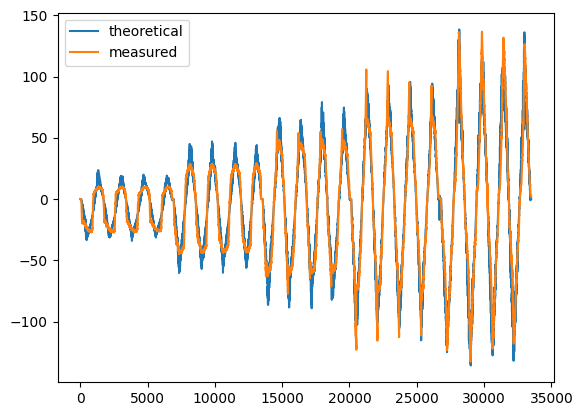

In [ ]:
%%time
c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma = optimal_params
beta = beta_gamma
gamma = beta_gamma
n = 2 #
f_r = []
y_dot_r = []
z_dot_r = []

z = 0
y = 0


f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

# Incorporating Savgol in optimization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

MR_data = pd.read_csv('data_voltagevarying.csv')
mask = MR_data['Time'].diff().shift(-1) < 0.01
MR_data = MR_data[~mask]
MR_data = MR_data.tail(33500)
t, x, dxdt, volt, f = MR_data['Time'], MR_data['Position'], MR_data['Velocity'], MR_data['Voltage'], MR_data['Force']
t, x, dxdt, volt, f = t.to_numpy(), x.to_numpy(), dxdt.to_numpy(), volt.to_numpy(), f.to_numpy()
MR_data.head()

,Time,Position,Velocity,Voltage,Force
9369,158.354933,-0.0,0.0,0.1,-0.0363
9370,158.370554,-0.0,0.0,0.1,-0.0363
9371,158.391178,-0.0,0.0,0.1,-0.0363
9372,158.407728,-0.0,0.0,0.1,-0.0408
9373,158.423351,-0.0,0.0,0.1,-0.0408


In [ ]:
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq
alpha_a_initial = 1921.141 #N/m
alpha_b_initial = 5882.51 #N/Vm
c_0a_initial = 651.4718 #Ns/m
c_0b_initial = 1043.7559 #Ns/Vm
c_1a_initial = 2089.263 #Ns/m
c_1b_initial = 14384.918 #Ns/Vm
k_0_initial = 1940.405 #N/m
k_1_initial = 1.751268 #N/m
A_initial = 155.32 # /m
beta_gamma_initial = 36332.07 # /m^2
n_initial = 2
ws_initial = 30
po_initial = 8


def residual(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = [c_0a_initial, c_0b_initial, c_1a_initial, c_1b_initial, alpha_a_initial, alpha_b_initial, k_0_initial, k_1_initial, A_initial, beta_gamma_initial, n_initial, ws_initial, po_initial]
result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)

<ipython-input-6-03cf4b6893fd>:60: RuntimeWarning: overflow encountered in double_scalars
  f_r.append(c_1 * dydt + k_1 * (x_i))
<ipython-input-6-03cf4b6893fd>:28: RuntimeWarning: overflow encountered in double_scalars
  term2 = k_0 * (x_i - y)


[ 1.65070082e+05 -3.33394399e+05  7.73489686e+01  2.40503784e+04
  1.92114100e+03  5.88251000e+03  2.60794449e+04  1.72270636e+02
  1.55320000e+02  3.63320700e+04  2.00000000e+00  3.00000000e+01
  8.00000000e+00]


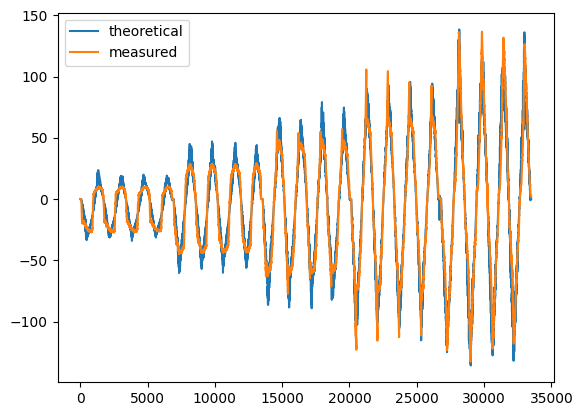

In [ ]:
c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))

f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

[ 1.65073317e+05 -3.33399584e+05  7.73465300e+01  2.40504070e+04
  1.92114100e+03  5.88251000e+03  2.60786039e+04  1.72270067e+02
  1.55320000e+02  3.63320700e+04  2.00000000e+00  3.00000000e+01
  8.00000000e+00]


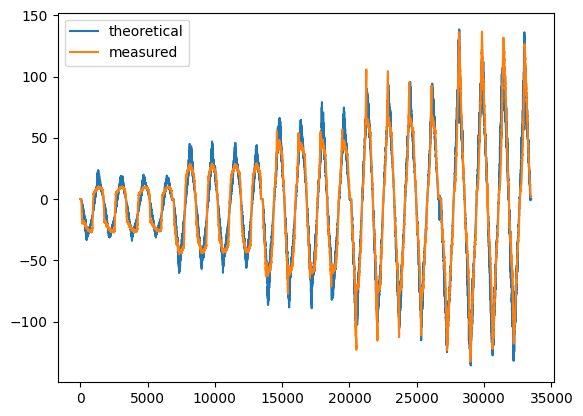

In [ ]:
optimal_params1 = optimal_params
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq

def residual(params, f, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = optimal_params1

result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

L = λ(data_loss(force_pred, force_true)) + γ(phys_loss(position, velocity, voltage))

# Nelder Mead Minimization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from scipy.optimize import minimize

MR_data = pd.read_csv('data_voltagevarying.csv')
mask = MR_data['Time'].diff().shift(-1) < 0.01
MR_data = MR_data[~mask]
MR_data = MR_data.tail(33500)
t, x, dxdt, volt, f = MR_data['Time'], MR_data['Position'], MR_data['Velocity'], MR_data['Voltage'], MR_data['Force']
t, x, dxdt, volt, f = t.to_numpy(), x.to_numpy(), dxdt.to_numpy(), volt.to_numpy(), f.to_numpy()
MR_data.head()

,Time,Position,Velocity,Voltage,Force
9369,158.354933,-0.0,0.0,0.1,-0.0363
9370,158.370554,-0.0,0.0,0.1,-0.0363
9371,158.391178,-0.0,0.0,0.1,-0.0363
9372,158.407728,-0.0,0.0,0.1,-0.0408
9373,158.423351,-0.0,0.0,0.1,-0.0408


In [ ]:
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    z = 0
    y = 0
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    f_r = []

    for i in range(len(t)-1):
        dt_i = (t[i+1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b*volt_i
        c_0 = c_0a + c_0b*volt_i
        c_1 = c_1a + c_1b*volt_i

        dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
        y += dydt*dt_i

        dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
        z += dzdt*dt_i

        f_r.append(c_1*dydt + k_1*(x_i))

    return f_r

    from scipy.optimize import minimize

alpha_a_initial = 1921.141 #N/m
alpha_b_initial = 5882.51 #N/Vm
c_0a_initial = 651.4718 #Ns/m
c_0b_initial = 1043.7559 #Ns/Vm
c_1a_initial = 2089.263 #Ns/m
c_1b_initial = 14384.918 #Ns/Vm
k_0_initial = 1940.405 #N/m
k_1_initial = 1.751268 #N/m
A_initial = 155.32 # /m
beta_gamma_initial = 36332.07 # /m^2
n_initial = 2
ws_initial = 30
po_initial = 8

initial_guess = [
    c_0a_initial,
    c_0b_initial,
    c_1a_initial,
    c_1b_initial,
    alpha_a_initial,
    alpha_b_initial,
    k_0_initial,
    k_1_initial,
    A_initial,
    beta_gamma_initial,
    n_initial,
    ws_initial,
    po_initial]

#parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
result = minimize(cost_function, initial_guess, args=(f, f_r), method='Nelder-Mead', bounds=parameter_bounds)

optimal_params = result.x
print(optimal_params)


[3.07897113e+03 1.36867790e+02 4.39216538e+02 2.32381539e+04
 2.30669243e+02 5.77497951e+04 1.00065178e+02 3.90023804e-01
 5.31861012e-01 1.04714995e+05 2.38095591e+00 1.29952152e+01
 5.53916125e+00]


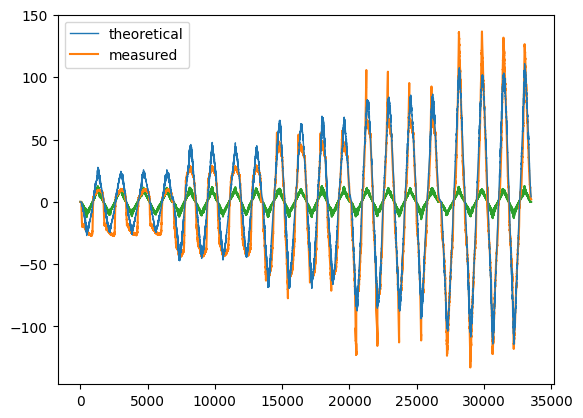

In [ ]:
c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
z = 0
y = 0
f_r_l = []
for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r_l.append(c_1*dydt + k_1*(x_i))

plt.plot(f_r_l,linewidth=1, zorder = 10)
plt.plot(f, zorder = 5)
plt.plot(dxdts*1000)
plt.legend(["theoretical", "measured"])

2nd run

[2.09312644e+00 2.37146629e+04 2.53597412e+03 1.99469642e+04
 2.31677941e+03 1.89992081e+06 2.25077829e+02 6.32688739e+01
 2.48039474e-02 7.00861790e+06 2.13937424e+00 2.30000815e+01
 3.99998474e+00]


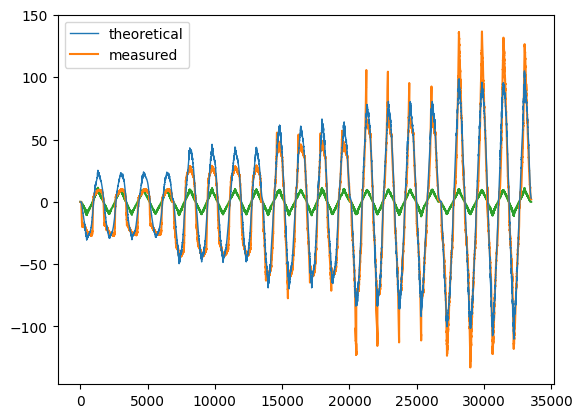

In [ ]:
initial_guess = optimal_params
parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
result = minimize(cost_function, initial_guess, args=(f, f_r), method='Nelder-Mead', bounds=parameter_bounds)
optimal_params = result.x
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
z = 0
y = 0
f_r_l = []
for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r_l.append(c_1*dydt + k_1*(x_i))

plt.plot(f_r_l,linewidth=1, zorder = 10)
plt.plot(f, zorder = 5)
plt.plot(dxdts*1000)
plt.legend(["theoretical", "measured"])

3rd

[3.32994725e-02 2.85864025e+01 4.85441941e+03 1.32342197e+04
 0.00000000e+00 1.96859864e+06 6.78170113e+00 1.73736040e+02
 9.12035788e-02 4.73245742e+07 2.24374845e+00 4.19995910e+01
 4.64621250e-02]


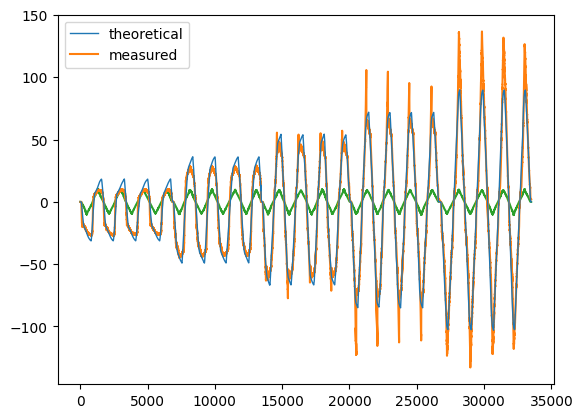

In [ ]:
initial_guess = optimal_params
parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
result = minimize(cost_function, initial_guess, args=(f, f_r), method='Nelder-Mead', bounds=parameter_bounds)
optimal_params = result.x
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
z = 0
y = 0
f_r_l = []
for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r_l.append(c_1*dydt + k_1*(x_i))

plt.plot(f_r_l,linewidth=1, zorder = 10)
plt.plot(f, zorder = 5)
plt.plot(dxdts*1000)
plt.legend(["theoretical", "measured"])

4th

[2.22550440e-02 1.43058145e-01 4.92740127e+03 1.30799457e+04
 2.55241768e-03 1.92581243e+06 4.29868653e-02 1.73247177e+02
 9.17821063e-02 4.79227169e+07 2.24966691e+00 4.30208564e+01
 1.99998462e+00]


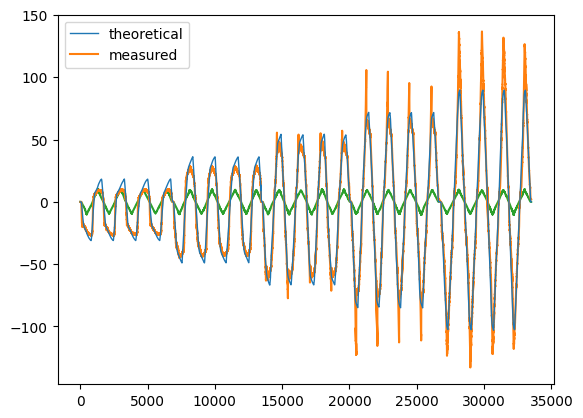

In [ ]:
initial_guess = optimal_params
parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
result = minimize(cost_function, initial_guess, args=(f, f_r), method='Nelder-Mead', bounds=parameter_bounds)
optimal_params = result.x
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
z = 0
y = 0
f_r_l = []
for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r_l.append(c_1*dydt + k_1*(x_i))

plt.plot(f_r_l,linewidth=1, zorder = 10)
plt.plot(f, zorder = 5)
plt.plot(dxdts*1000)
plt.legend(["theoretical", "measured"])

5th

[1.73943055e-03 2.85342988e-01 4.91911305e+03 1.31067849e+04
 2.70419830e-02 1.78367298e+06 9.15177641e-03 1.71892495e+02
 9.24753639e-02 6.39454401e+07 2.29929207e+00 4.59997820e+01
 1.84372373e+00]


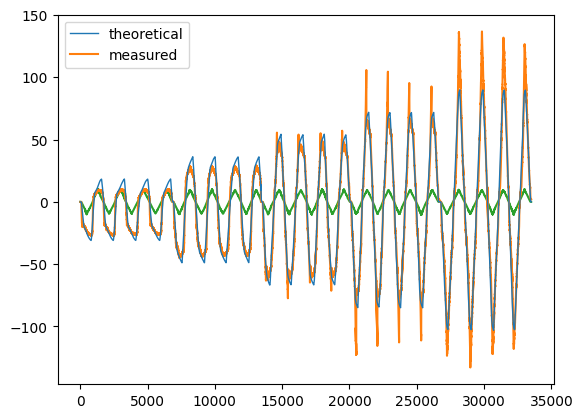

In [ ]:
initial_guess = optimal_params
parameter_bounds = [(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, None),(0, 3),(0, 100), (0, 50)]
result = minimize(cost_function, initial_guess, args=(f, f_r), method='Nelder-Mead', bounds=parameter_bounds)
optimal_params = result.x
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
z = 0
y = 0
f_r_l = []
for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r_l.append(c_1*dydt + k_1*(x_i))

plt.plot(f_r_l,linewidth=1, zorder = 10)
plt.plot(f, zorder = 5)
plt.plot(dxdts*1000)
plt.legend(["theoretical", "measured"])

# LS with altered NM params

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from scipy.optimize import minimize

MR_data = pd.read_csv('data_voltagevarying.csv')
mask = MR_data['Time'].diff().shift(-1) < 0.01
MR_data = MR_data[~mask]
MR_data = MR_data.tail(33500)
t, x, dxdt, volt, f = MR_data['Time'], MR_data['Position'], MR_data['Velocity'], MR_data['Voltage'], MR_data['Force']
t, x, dxdt, volt, f = t.to_numpy(), x.to_numpy(), dxdt.to_numpy(), volt.to_numpy(), f.to_numpy()
MR_data.head()

,Time,Position,Velocity,Voltage,Force
9369,158.354933,-0.0,0.0,0.1,-0.0363
9370,158.370554,-0.0,0.0,0.1,-0.0363
9371,158.391178,-0.0,0.0,0.1,-0.0363
9372,158.407728,-0.0,0.0,0.1,-0.0408
9373,158.423351,-0.0,0.0,0.1,-0.0408


In [ ]:
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq

def residual(params, f, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = [
    1.73943055e-03,
    2.85342988e-01,
    4.91911305e+03,
    1.31067849e+04,
    2.70419830e-02,
    1.78367298e+06,
    9.15177641e-03,
    1.71892495e+02,
    9.24753639e-02,
    6.39454401e+07,
    2.29929207e+00,
    4.59997820e+01,
    1.84372373e+00]

result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)


[ 9.69099656e+01  2.28249975e+04  7.56357177e+13 -3.78146226e+14
  2.70419830e-02  1.78367298e+06 -5.76689675e+04  5.78920572e+04
  9.24753639e-02  6.39454401e+07  2.29929207e+00  4.59997820e+01
  1.84372373e+00]


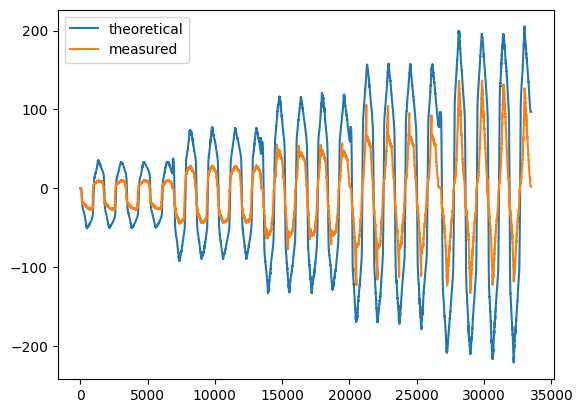

In [ ]:
c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

2nd

In [ ]:
optimal_params1 = optimal_params
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq

def residual(params, f, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = optimal_params1

result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)


[ 9.69101291e+01  2.28249966e+04  8.46688917e+13 -4.23309789e+14
  2.70419830e-02  1.78367298e+06 -5.96906119e+04  5.99137025e+04
  9.24753639e-02  6.39454401e+07  2.29929207e+00  4.59997820e+01
  1.84372373e+00]


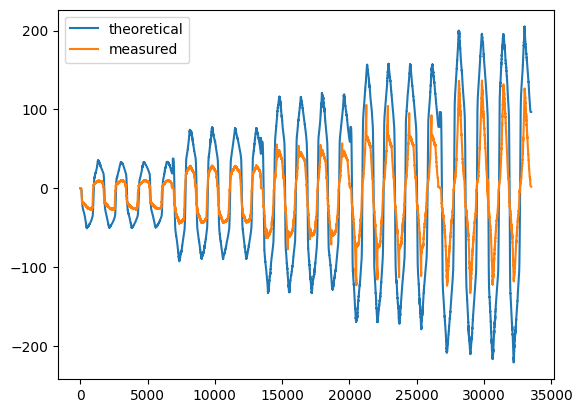

In [ ]:
c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

3rd

[ 9.69171502e+01  2.28249774e+04  8.75428282e+13 -4.37678645e+14
  2.70419830e-02  1.78367298e+06 -6.03978316e+04  6.06209225e+04
  9.24753639e-02  6.39454401e+07  2.29929207e+00  4.59997820e+01
  1.84372373e+00]


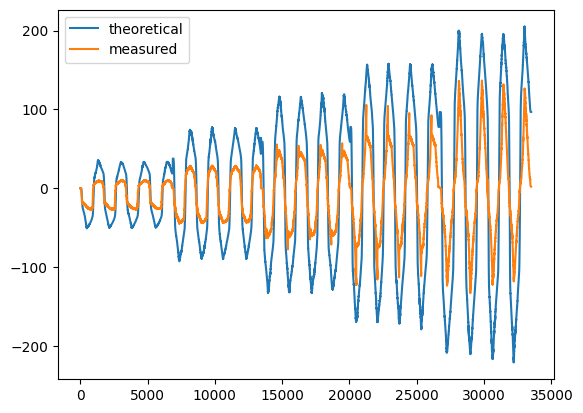

In [ ]:
optimal_params1 = optimal_params
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq

def residual(params, f, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = optimal_params1

result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])

[ 9.69105794e+01  2.28249953e+04  8.98157264e+13 -4.49042355e+14
  2.70419830e-02  1.78367298e+06 -6.10586379e+04  6.12817291e+04
  9.24753639e-02  6.39454401e+07  2.29929207e+00  4.59997820e+01
  1.84372373e+00]


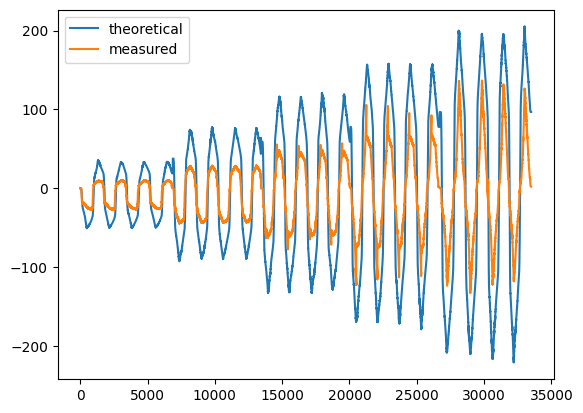

In [ ]:
optimal_params1 = optimal_params
def cost_function(params, f1, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    squared_errors = (f1[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po))**2
    return np.sum(squared_errors)

def f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po):
    beta = beta_gamma
    gamma = beta_gamma
    dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
    z = 0
    y = 0

    f_r = []

    for i in range(len(t) - 1):
        dt_i = (t[i + 1] - t[i])
        x_i = x[i]
        dxdt_i = dxdts[i]
        volt_i = volt[i]
        alpha = alpha_a + alpha_b * volt_i
        c_0 = c_0a + c_0b * volt_i
        c_1 = c_1a + c_1b * volt_i

        if c_0 + c_1 != 0:
            term1 = alpha * z
            #term2 = k_0 * (x_i - y)
            if not (np.isinf(k_0) or np.isinf(x_i) or np.isinf(y)):
                term2 = k_0 * (x_i - y)
            else:
                term2 = 0  # Handle overflow
            term3 = c_0 * dxdt_i

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dydt = (term1 + term2 + term3) / (c_0 + c_1)
            else:
                dydt = 0  # Handle overflow
        else:
            dydt = 0  # Handle division by zero
        y += dydt * dt_i


        if np.abs(z) != 0:  # Check for division by zero or invalid values
            term1 = -gamma * np.abs(dxdt_i - dydt) * z
            term2 = -beta * (dxdt_i - dydt)
            term3 = A * (dxdt_i - dydt)

            # Check for overflow
            if not (np.isinf(term1) or np.isinf(term2) or np.isinf(term3)):
                dzdt = term1 * np.power(np.abs(z), n - 1) - term2 * np.power(np.abs(z), n) + term3
            else:
                dzdt = 0  # Handle overflow
        else:
            dzdt = 0  # Handle division by zero or invalid values

        z += dzdt * dt_i

        #f_r.append(c_1 * dydt + k_1 * (x_i))
        if not (np.isinf(c_1) or np.isinf(dydt) or np.isinf(k_1)):
            f_r.append(c_1 * dydt + k_1 * (x_i))
        else:
            f_r.append(0)  # Handle overflow

    return f_r

from scipy.optimize import leastsq

def residual(params, f, f_r):
    c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = params
    return f[:-1] - f_r(c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po)

initial_guess = optimal_params1

result = leastsq(residual, initial_guess, args=(f, f_r))
optimal_params = result[0]
print(optimal_params)

c_0a, c_0b, c_1a, c_1b, alpha_a, alpha_b, k_0, k_1, A, beta_gamma, n, ws, po = optimal_params
beta = beta_gamma
gamma = beta_gamma
f_r = []
y_dot_r = []
z_dot_r = []
z = 0
y = 0

dxdts = savgol_filter(dxdt, window_length=int(ws), polyorder=int(po))
f_r = []

for i in range(len(t)-1):
    dt_i = (t[i+1] - t[i])
    x_i = x[i]
    dxdt_i = dxdts[i]
    volt_i = volt[i]
    alpha = alpha_a + alpha_b*volt_i
    c_0 = c_0a + c_0b*volt_i
    c_1 = c_1a + c_1b*volt_i

    dydt = ((alpha)*z + k_0*(x_i-y) + (c_0)*dxdt_i)/(c_0 + c_1)
    y += dydt*dt_i

    dzdt = -gamma*np.abs(dxdt_i-dydt)*z*np.power(np.abs(z),n-1) - beta*(dxdt_i-dydt)*np.power(np.abs(z),n) + A*(dxdt_i - dydt)
    z += dzdt*dt_i


    f_r.append(c_1*dydt + k_1*(x_i))
plt.plot(f_r)
plt.plot(f)

plt.legend(["theoretical", "measured"])